# Práctica 1 - Procesamiento del corpus

El notebook sigue el orden de la rúbrica. Los archivos `.txt` del corpus son la fuente original y no se sobrescriben durante el preprocesamiento.

In [3]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
CORPUS_DIR = ROOT / "corpus"
METADATA_PATH = CORPUS_DIR / "metadata.csv"
metadata = pd.read_csv(METADATA_PATH)
metadata.head()

,doc_id,label,source_type,source_name,url,title,date,n_words,topic,file,original_id
0,ds_falso_0001,0,dataset,fuente2_kaggle,NaN,El órgano que fiscaliza al Gobierno andaluz de...,NaN,58,politica,Falso/ds_falso_0001.txt,ID
1,ds_falso_0002,0,dataset,fuente2_kaggle,NaN,PP pide a Cristina Narbona igualar los permiso...,NaN,50,politica,Falso/ds_falso_0002.txt,ID
2,ds_falso_0003,0,dataset,fuente2_kaggle,NaN,Cristina Narbona rebaja las hipótesis electora...,NaN,49,politica,Falso/ds_falso_0003.txt,ID
3,ds_falso_0004,0,dataset,fuente2_kaggle,NaN,"Carrero Blanco, elegida candidata del Iniciati...",NaN,47,politica,Falso/ds_falso_0004.txt,ID
4,ds_falso_0005,0,dataset,fuente2_kaggle,NaN,Diego Cañamero pide aprobar ya los presupuesto...,NaN,40,politica,Falso/ds_falso_0005.txt,ID


## 1. Creación y caracterización del corpus

El corpus definitivo contiene 5.300 documentos: 5.000 del dataset de Kaggle y 300 obtenidos mediante web scraping. La generación se realiza con `src/get_corpus_dataset.py` y `src/scrape_corpus.py`; cada script conserva los archivos de la otra fuente.

In [4]:
metadata["label_name"] = metadata["label"].map({0: "Falso", 1: "Verdad"})
metadata.groupby(["source_name", "label_name"]).size().unstack(fill_value=0)

label_name,Falso,Verdad
source_name,,
bbc_mundo,0,150
fuente2_kaggle,2500,2500
newtral,150,0


In [5]:
metrics = (
    metadata.groupby("source_name")["n_words"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        max="max",
        q25=lambda values: values.quantile(0.25),
        q50=lambda values: values.quantile(0.50),
        q75=lambda values: values.quantile(0.75),
        sum="sum",
    )
    .rename(columns={"count": "Count", "mean": "Mean", "std": "Std", "min": "Min", "max": "Max", "q25": "Q25", "q50": "Q50", "q75": "Q75", "sum": "Sum"})
    .round(2)
)
metrics

,Count,Mean,Std,Min,Max,Q25,Q50,Q75,Sum
source_name,,,,,,,,,
bbc_mundo,150,1176.32,822.18,61,3940,591.5,1058.5,1651.25,176448
fuente2_kaggle,5000,54.20,15.78,20,177,44.0,53.0,62.00,271012
newtral,150,753.59,894.53,220,10762,471.5,608.5,806.50,113039


In [6]:
assert len(metadata) == 5300
assert metadata["label"].value_counts().to_dict() == {0: 2650, 1: 2650}
assert metadata["source_name"].value_counts().to_dict() == {"fuente2_kaggle": 5000, "newtral": 150, "bbc_mundo": 150}
assert all((CORPUS_DIR / row.file).exists() for row in metadata.itertuples())
print("Corpus válido: 5.300 documentos.")

Corpus válido: 5.300 documentos.


## 2. Preprocesamiento

Esta fase se ejecuta después de crear el corpus. Incluye minúsculas, eliminación de tildes, números, URLs, saltos de línea, HTML, puntuación y emoticones. El resultado se guarda en una columna nueva para conservar el texto crudo.

In [7]:
from src.preprocess import clean_text, preprocess_dataframe

# Carga explícita del texto original desde los TXT.
metadata["text"] = metadata["file"].map(
    lambda relative_path: (CORPUS_DIR / relative_path).read_text(encoding="utf-8")
)
processed = preprocess_dataframe(metadata, text_column="text", output_column="clean_text")
processed[["doc_id", "label_name", "text", "clean_text"]].head(3)

,doc_id,label_name,text,clean_text
0,ds_falso_0001,Falso,El órgano que fiscaliza al Gobierno andaluz de...,el organo que fiscaliza al gobierno andaluz de...
1,ds_falso_0002,Falso,PP pide a Cristina Narbona igualar los permiso...,pp pide a cristina narbona igualar los permiso...
2,ds_falso_0003,Falso,Cristina Narbona rebaja las hipótesis electora...,cristina narbona rebaja las hipotesis electora...


In [8]:
# Verificación de que el preprocesamiento no sobrescribió los archivos fuente.
assert metadata["text"].str.len().sum() > processed["clean_text"].str.len().sum()
assert processed["clean_text"].map(lambda value: value == value.lower()).all()
assert not processed["clean_text"].str.contains(r"https?://|www\.", regex=True).any()
print("Preprocesamiento aplicado sobre una copia en memoria.")

Preprocesamiento aplicado sobre una copia en memoria.


## 3. Análisis lingüístico mediante POS Tagging

Se procesa cada documento con el modelo español `es_core_news_sm`. El análisis se realiza por separado para noticias verdaderas (`label=1`) y falsas (`label=0`). Las frecuencias relativas de la tabla se calculan sobre el total de tokens pertenecientes a las cinco categorías POS exigidas, por lo que cada clase suma 100%.

In [9]:
from src.pos_ner import (
    load_spanish_model,
    analyze_pos,
    comparative_table,
    top_words,
    plot_pos_distribution,
    save_pos_results,
)

nlp = load_spanish_model("es_core_news_sm")
pos_counts, word_counts = analyze_pos(
    metadata,
    nlp,
    text_column="text",
    label_column="label",
)
pos_table = comparative_table(pos_counts)
pos_table

,Verdaderas (cantidad),Verdaderas (%),Falsas (cantidad),Falsas (%)
POS,,,,
ADJ,20893.0,14.95,16293.0,15.06
ADV,9896.0,7.08,6589.0,6.09
NOUN,63003.0,45.08,51182.0,47.31
PRON,14407.0,10.31,9499.0,8.78
VERB,31572.0,22.59,24617.0,22.76


In [10]:
# Sumar la columna Verdaderas (%) del DataFrame pos_table
print(pos_table['Verdaderas (%)'].sum())

100.01


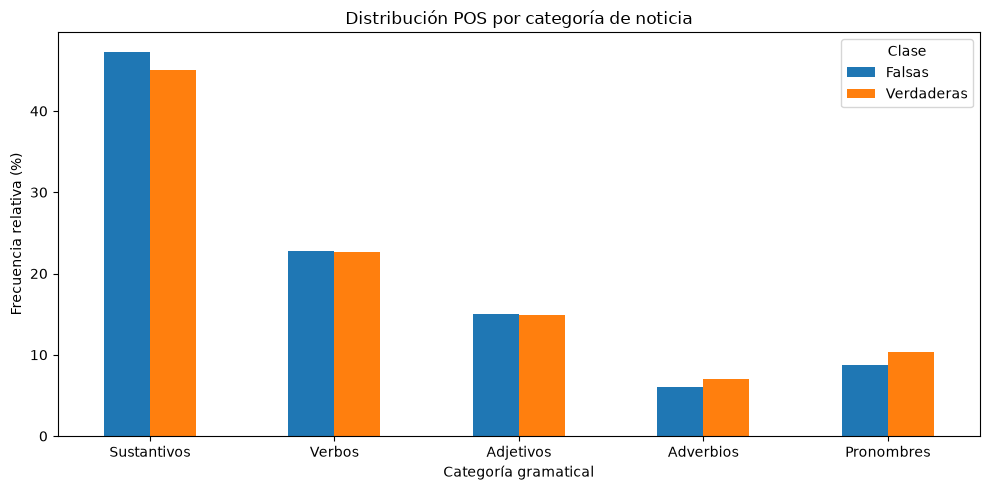

In [11]:
import matplotlib.pyplot as plt

pos_figure = plot_pos_distribution(pos_counts)
display(pos_figure)
RESULTS_POS_DIR = ROOT / "results" / "pos_ner"
RESULTS_POS_DIR.mkdir(parents=True, exist_ok=True)
pos_figure.savefig(RESULTS_POS_DIR / "pos_distribution.png", dpi=160, bbox_inches="tight")
plt.close(pos_figure)
pos_table.to_csv(RESULTS_POS_DIR / "pos_comparative_table.csv", encoding="utf-8")

In [12]:
top_nouns_true = top_words(word_counts, label=1, pos="NOUN", n=10)
top_nouns_false = top_words(word_counts, label=0, pos="NOUN", n=10)
top_verbs_true = top_words(word_counts, label=1, pos="VERB", n=10)
top_verbs_false = top_words(word_counts, label=0, pos="VERB", n=10)
top_adjectives_true = top_words(word_counts, label=1, pos="ADJ", n=10)
top_adjectives_false = top_words(word_counts, label=0, pos="ADJ", n=10)

display(top_nouns_true)
display(top_nouns_false)
display(top_verbs_true)
display(top_verbs_false)
display(top_adjectives_true)
display(top_adjectives_false)

,label,noticia,POS,token,frecuencia
0,1,Verdaderas,NOUN,año,857
1,1,Verdaderas,NOUN,país,562
2,1,Verdaderas,NOUN,presidente,454
3,1,Verdaderas,NOUN,persona,400
4,1,Verdaderas,NOUN,partido,363
5,1,Verdaderas,NOUN,gobierno,354
6,1,Verdaderas,NOUN,parte,351
7,1,Verdaderas,NOUN,día,337
8,1,Verdaderas,NOUN,caso,329
9,1,Verdaderas,NOUN,acuerdo,292


,label,noticia,POS,token,frecuencia
0,0,Falsas,NOUN,partido,502
1,0,Falsas,NOUN,vídeo,448
2,0,Falsas,NOUN,presidente,427
3,0,Falsas,NOUN,vers,399
4,0,Falsas,NOUN,año,388
5,0,Falsas,NOUN,persona,365
6,0,Falsas,NOUN,ley,331
7,0,Falsas,NOUN,caso,316
8,0,Falsas,NOUN,red,299
9,0,Falsas,NOUN,imagen,295


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,VERB,tener,999
1,1,Verdaderas,VERB,hacer,751
2,1,Verdaderas,VERB,decir,693
3,1,Verdaderas,VERB,pedir,386
4,1,Verdaderas,VERB,dar,367
5,1,Verdaderas,VERB,recibir,320
6,1,Verdaderas,VERB,seguir,301
7,1,Verdaderas,VERB,llegar,297
8,1,Verdaderas,VERB,ver,280
9,1,Verdaderas,VERB,asegurar,274


,label,noticia,POS,token,frecuencia
0,0,Falsas,VERB,tener,686
1,0,Falsas,VERB,hacer,496
2,0,Falsas,VERB,asegurar,413
3,0,Falsas,VERB,pedir,334
4,0,Falsas,VERB,decir,329
5,0,Falsas,VERB,afirmar,257
6,0,Falsas,VERB,dar,252
7,0,Falsas,VERB,señalar,207
8,0,Falsas,VERB,explicar,201
9,0,Falsas,VERB,presentar,191


,label,noticia,POS,token,frecuencia
0,1,Verdaderas,ADJ,nuevo,537
1,1,Verdaderas,ADJ,primero,388
2,1,Verdaderas,ADJ,político,289
3,1,Verdaderas,ADJ,último,262
4,1,Verdaderas,ADJ,público,206
5,1,Verdaderas,ADJ,importante,196
6,1,Verdaderas,ADJ,social,182
7,1,Verdaderas,ADJ,mayor,170
8,1,Verdaderas,ADJ,solo,168
9,1,Verdaderas,ADJ,económico,167


,label,noticia,POS,token,frecuencia
0,0,Falsas,ADJ,nuevo,358
1,0,Falsas,ADJ,social,337
2,0,Falsas,ADJ,político,248
3,0,Falsas,ADJ,primero,247
4,0,Falsas,ADJ,español,220
5,0,Falsas,ADJ,público,208
6,0,Falsas,ADJ,último,196
7,0,Falsas,ADJ,general,172
8,0,Falsas,ADJ,viral,133
9,0,Falsas,ADJ,electoral,132


In [13]:
paths_pos = save_pos_results(pos_counts, word_counts, RESULTS_POS_DIR)
paths_pos

{'pos_counts': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_frequencies.csv'),
 'word_counts': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_token_frequencies.csv'),
 'table': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_comparative_table.csv'),
 'figure': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/pos_ner/pos_distribution.png')}

### Interpretación inicial

La tabla y el gráfico permiten comparar la proporción de cada categoría respecto del total de tokens de las cinco categorías analizadas en cada clase. Si se dividiera entre todos los tokens del corpus, las proporciones no sumarían 100% porque se omitirían otras etiquetas POS, como determinantes, artículos, adposiciones y conjunciones. Las diferencias deben interpretarse junto con la longitud y el tema de las noticias: una mayor frecuencia relativa no demuestra por sí sola que una categoría gramatical sea un indicador suficiente de falsedad.

## 4. Reconocimiento de Entidades Nombradas (NER)

Se extraen las entidades reconocidas por spaCy sobre el texto crudo. Cada fila representa una mención y conserva el documento, la clase, el texto de la entidad y su tipo. Las repeticiones se mantienen porque son necesarias para calcular frecuencias.

In [14]:
from src.pos_ner import (
    extract_entities,
    summarize_entities,
    entity_type_distribution,
    top_global_entities,
    plot_ner_distribution,
    plot_top_entities,
    save_ner_results,
)

ner_entities = extract_entities(metadata, nlp, text_column="text", label_column="label")
ner_summaries = summarize_entities(ner_entities, top_n=10)

print(f"Menciones detectadas: {len(ner_entities):,}")
print(f"Documentos con entidades: {ner_entities['doc_id'].nunique():,}")
display(ner_entities.head())

Menciones detectadas: 50,648
Documentos con entidades: 5,286


,doc_id,label,clase,entidad,tipo
0,ds_falso_0001,0,Falsas,Gobierno andaluz,LOC
1,ds_falso_0001,0,Falsas,Junta,MISC
2,ds_falso_0001,0,Falsas,Consejería de Agricultura,LOC
3,ds_falso_0001,0,Falsas,Carmen Crespo,PER
4,ds_falso_0001,0,Falsas,BNG,ORG


In [15]:
# Total de entidades y distribución porcentual por tipo dentro de cada clase.
ner_by_class = ner_summaries["by_class"]
ner_type_distribution = entity_type_distribution(ner_entities)
display(ner_by_class)
display(ner_type_distribution)

,label,clase,menciones,entidades_unicas,documentos
0,0,Falsas,24207,8025,2646
1,1,Verdaderas,26441,9994,2640


,label,clase,tipo,menciones,documentos,porcentaje
0,0,Falsas,LOC,7643,2084,31.573512
1,0,Falsas,PER,6091,2242,25.162143
2,0,Falsas,MISC,5690,2041,23.505598
3,0,Falsas,ORG,4783,1867,19.758747
4,1,Verdaderas,LOC,8765,2072,33.149276
5,1,Verdaderas,MISC,6651,2015,25.154117
6,1,Verdaderas,PER,6617,1878,25.025529
7,1,Verdaderas,ORG,4408,1733,16.671079


In [16]:
# Diez entidades más frecuentes por tipo para cada clase.
ner_top_by_type = ner_summaries["top_entities"]
display(ner_top_by_type[ner_top_by_type["label"] == 1])
display(ner_top_by_type[ner_top_by_type["label"] == 0])

,label,clase,tipo,entidad,frecuencia
40,1,Verdaderas,LOC,Gobierno,343
41,1,Verdaderas,LOC,EE.UU.,245
42,1,Verdaderas,LOC,Venezuela,245
43,1,Verdaderas,LOC,Colombia,160
44,1,Verdaderas,LOC,Estados Unidos,151
45,1,Verdaderas,LOC,Madrid,149
46,1,Verdaderas,LOC,Estado,136
47,1,Verdaderas,LOC,Reino Unido,96
48,1,Verdaderas,LOC,Cuba,92
49,1,Verdaderas,LOC,Argentina,88


,label,clase,tipo,entidad,frecuencia
0,0,Falsas,LOC,Ceuta,619
1,0,Falsas,LOC,Gobierno,506
2,0,Falsas,LOC,Marruecos,236
3,0,Falsas,LOC,Madrid,216
4,0,Falsas,LOC,Coalición Canaria,205
5,0,Falsas,LOC,España,190
6,0,Falsas,LOC,Nueva Canarias,184
7,0,Falsas,LOC,Qué,126
8,0,Falsas,LOC,Melilla,96
9,0,Falsas,LOC,Comunidad de Madrid,92


In [17]:
# Veinte entidades más frecuentes globalmente por categoría.
ner_top_true = top_global_entities(ner_entities, label=1, n=20)
ner_top_false = top_global_entities(ner_entities, label=0, n=20)
display(ner_top_true)
display(ner_top_false)

,label,clase,entidad,frecuencia
0,1,Verdaderas,PP,590
1,1,Verdaderas,Gobierno,394
2,1,Verdaderas,PSOE,330
3,1,Verdaderas,EE.UU.,245
4,1,Verdaderas,Venezuela,245
5,1,Verdaderas,Vox,231
6,1,Verdaderas,Congreso,181
7,1,Verdaderas,España,178
8,1,Verdaderas,También,174
9,1,Verdaderas,Colombia,160


,label,clase,entidad,frecuencia
0,0,Falsas,Ceuta,619
1,0,Falsas,Gobierno,566
2,0,Falsas,Iniciativa vers per Catalunya,474
3,0,Falsas,España,393
4,0,Falsas,PP,310
5,0,Falsas,BNG,279
6,0,Falsas,Cristina Narbona,245
7,0,Falsas,Congreso,237
8,0,Falsas,EQUO,236
9,0,Falsas,Marruecos,236


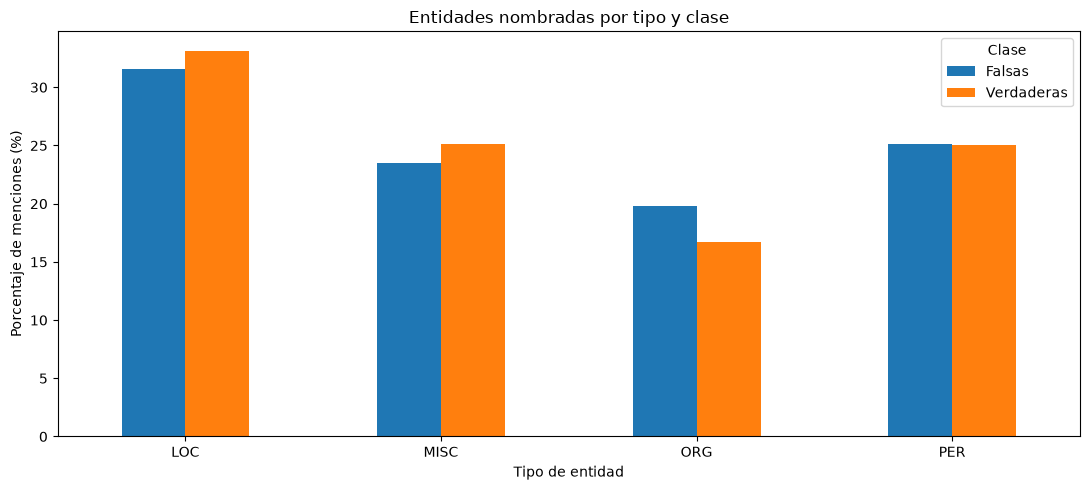

In [18]:
import matplotlib.pyplot as plt

RESULTS_NER_DIR = ROOT / "results" / "ner"
RESULTS_NER_DIR.mkdir(parents=True, exist_ok=True)

ner_distribution_figure = plot_ner_distribution(ner_entities)
display(ner_distribution_figure)
ner_distribution_figure.savefig(RESULTS_NER_DIR / "ner_distribution.png", dpi=160, bbox_inches="tight")
plt.close(ner_distribution_figure)

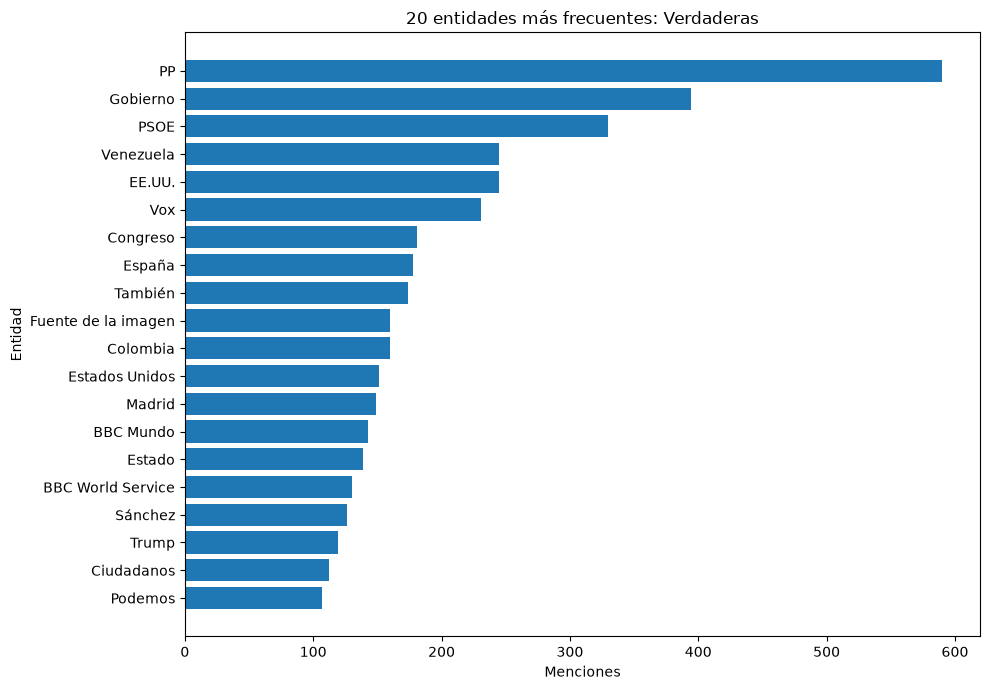

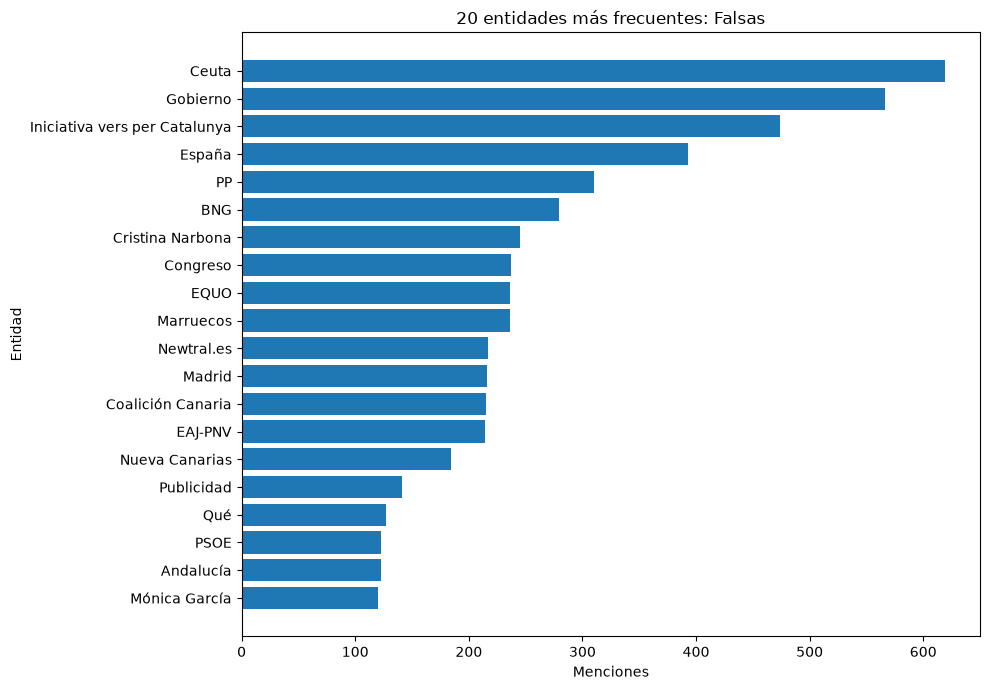

In [19]:
true_figure = plot_top_entities(ner_entities, label=1, n=20)
false_figure = plot_top_entities(ner_entities, label=0, n=20)
display(true_figure)
display(false_figure)
true_figure.savefig(RESULTS_NER_DIR / "ner_top_verdaderas.png", dpi=160, bbox_inches="tight")
false_figure.savefig(RESULTS_NER_DIR / "ner_top_falsas.png", dpi=160, bbox_inches="tight")
plt.close(true_figure)
plt.close(false_figure)

In [20]:
ner_paths = save_ner_results(ner_entities, RESULTS_NER_DIR, top_n=10)
ner_paths

{'entities': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_entities.csv'),
 'summary': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_summary.csv'),
 'by_type': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_by_type.csv'),
 'top_entities': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_entities.csv'),
 'by_class': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_by_class.csv'),
 'type_distribution': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_type_distribution.csv'),
 'top_global_true': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_global_verdaderas.csv'),
 'top_global_false': WindowsPath('C:/Users/maria/OneDrive/Documentos/2026/PLN/Noticias-Falsas/results/ner/ner_top_global_falsas.csv'

### Revisión de errores del modelo

Las predicciones de NER no incluyen una anotación de referencia en el corpus, por lo que los errores deben validarse manualmente. Para el informe se deben seleccionar al menos cinco casos de `ner_entities` y documentar si son falsos positivos, categorías incorrectas o entidades omitidas. La revisi?n debe incluir el fragmento original, la predicción del modelo, la categoría esperada y la justificación.

## 5. Extracción de características

En esta sección se usarán unigramas, bigramas, stopwords, stemming, términos de ocurrencia y TF-IDF mediante `src/features.py`.

In [21]:
import importlib
import src.topic_modeling as topic_modeling
topic_modeling = importlib.reload(topic_modeling)
SOURCE_BOILERPLATE = topic_modeling.SOURCE_BOILERPLATE

import src.features as features
features = importlib.reload(features)
preprocess_for_features = features.preprocess_for_features
extract_features = features.extract_features

processed = features.preprocess_for_features(
    processed,
    text_column='clean_text',
    output_column='text_stemmed',
    apply_stopwords=True,
    apply_stemming=True,
    extra_stopwords=SOURCE_BOILERPLATE,
)
processed[['clean_text', 'text_stemmed']].head()


,clean_text,text_stemmed
0,el organo que fiscaliza al gobierno andaluz de...,organ fiscaliz gobiern andaluz defiend legal n...
1,pp pide a cristina narbona igualar los permiso...,pp pid cristin narbon igual permis patern mate...
2,cristina narbona rebaja las hipotesis electora...,cristin narbon rebaj hipotesis electoral abal ...
3,carrero blanco elegida candidata del iniciativ...,carrer blanc eleg candidat inici vers per cata...
4,diego cañamero pide aprobar ya los presupuesto...,dieg cañamer pid aprob presupuest catalan pali...


In [22]:
# 2. Extracción de características con Unigramas y Bigramas (Frecuencia < 3 eliminada)
print("Extrayendo características (BoW)...")

# Utilizando method='bow' para cumplir estrictamente con el requerimiento de Bolsa de Palabras
X_features, vectorizer = extract_features(
    processed, 
    text_column='text_stemmed', 
    method='bow', 
    min_freq=3
)

print(f"Matriz de características creada con éxito.")
print(f"Número de documentos: {X_features.shape[0]}")
print(f"Total de características (unigramas y bigramas válidos): {X_features.shape[1]}")

Extrayendo características (BoW)...
Matriz de características creada con éxito.
Número de documentos: 5300
Total de características (unigramas y bigramas válidos): 19024


In [23]:
import numpy as np
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
freq = np.asarray(X_features.sum(axis=0)).ravel()
top = pd.DataFrame({"término": feature_names, "frecuencia": freq}).sort_values("frecuencia", ascending=False)

print("Unigramas más frecuentes:")
display(top[~top["término"].str.contains(" ")].head(10))
print("Bigramas más frecuentes:")
display(top[top["término"].str.contains(" ")].head(10))

Unigramas más frecuentes:


,término,frecuencia
7994,gobiern,2176
12779,part,1656
14184,president,1393
12097,nuev,1210
14779,public,1096
13955,pp,1045
2651,cas,1013
13734,polit,966
16900,social,958
10485,madr,952


Bigramas más frecuentes:


,término,frecuencia
13163,per cataluny,607
9198,inici vers,605
18515,vers per,605
5818,eaj pnv,302
15387,red social,287
4289,cristin narbon,260
3316,coalicion canari,244
14238,president gobiern,235
12105,nuev canari,215
3608,comun madr,202


## 6. Modelado de temas

Se construyen las matrices con ponderación por frecuencia absoluta (TO) y TF-IDF, usando el mismo vocabulario de unigramas y bigramas

In [24]:
from src.features import extract_features

print("PUNTO 6: Ponderación de Características\n" + "-"*40)

# 1. Frecuencia Absoluta (Term Occurrences - TO)
print("Generando ponderación por Frecuencia Absoluta (TO)...")
X_to, vectorizer_to = extract_features(processed, text_column='text_stemmed', method='bow', min_freq=3)

# 2. Esquema TF-IDF
print("Generando ponderación por TF-IDF...")
X_tfidf, vectorizer_tfidf = extract_features(processed, text_column='text_stemmed', method='tfidf', min_freq=3)

print(f"\nDimensiones de la matriz TO (BoW): {X_to.shape}")
print(f"Dimensiones de la matriz TF-IDF: {X_tfidf.shape}")

PUNTO 6: Ponderación de Características
----------------------------------------
Generando ponderación por Frecuencia Absoluta (TO)...
Generando ponderación por TF-IDF...

Dimensiones de la matriz TO (BoW): (5300, 19024)
Dimensiones de la matriz TF-IDF: (5300, 19024)


## 7. Clasificación

En esta sección se compararán cuatro algoritmos y ocho configuraciones usando validación cruzada mediante `src/classify.py`.a

El modelado de temas es no supervisado. Para no fijar el número de temas k de forma arbitraria,
se calcula el Score de Coherencia (c_v) para k = 2..10 (7.3) y se usa el k elegido en LSA (7.1) y LDA (7.2).

In [25]:
import importlib
import src.features as features
features = importlib.reload(features)
import src.topic_modeling as topic_modeling
topic_modeling = importlib.reload(topic_modeling)

SOURCE_BOILERPLATE = topic_modeling.SOURCE_BOILERPLATE
prepare_gensim_corpus = topic_modeling.prepare_gensim_corpus
prepare_sklearn_corpus = topic_modeling.prepare_sklearn_corpus
calculate_coherence_values = topic_modeling.calculate_coherence_values
plot_coherence = topic_modeling.plot_coherence
run_lsa = topic_modeling.run_lsa
run_lda = topic_modeling.run_lda

textos_limpios = processed["clean_text"].tolist()
try:
    dictionary, corpus, tokenized_texts = prepare_gensim_corpus(
        textos_limpios, extra_stopwords=SOURCE_BOILERPLATE
    )
    topic_backend = "gensim"
except ImportError:
    corpus, dictionary, tokenized_texts = prepare_sklearn_corpus(
        textos_limpios, extra_stopwords=SOURCE_BOILERPLATE
    )
    topic_backend = "scikit-learn"

print(f"Backend de t?picos: {topic_backend}")
vocabulary_size = (len(dictionary.get_feature_names_out())
                   if topic_backend == "scikit-learn" else len(dictionary))
document_count = (corpus.shape[0]
                  if topic_backend == "scikit-learn" else len(corpus))
print(f"Vocabulario: {vocabulary_size} t?rminos | Documentos: {document_count}")


Backend de t?picos: gensim
Vocabulario: 7584 t?rminos | Documentos: 5300


Calculamos la coherencia para $k$ entre 2 y 10

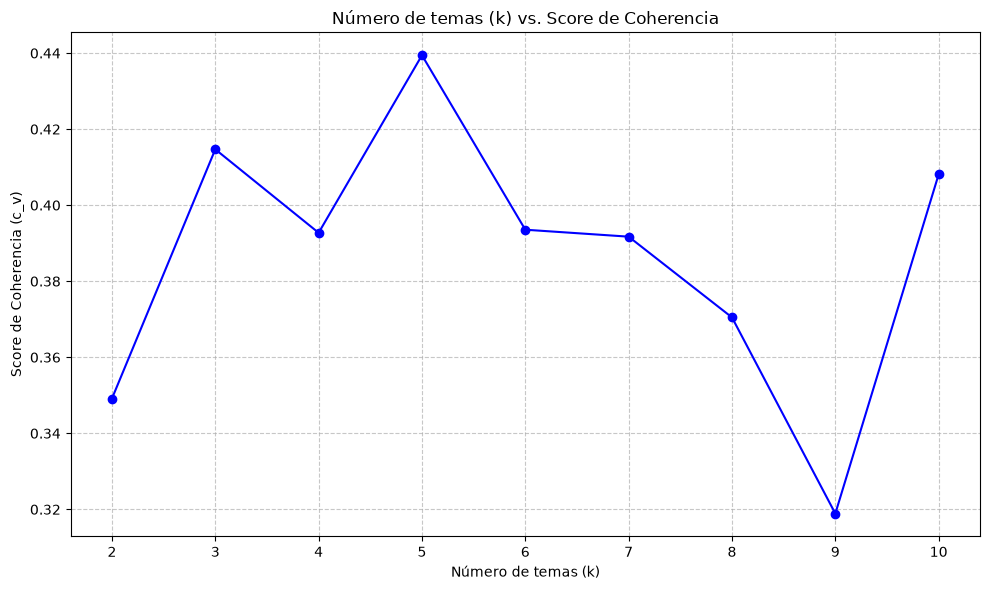

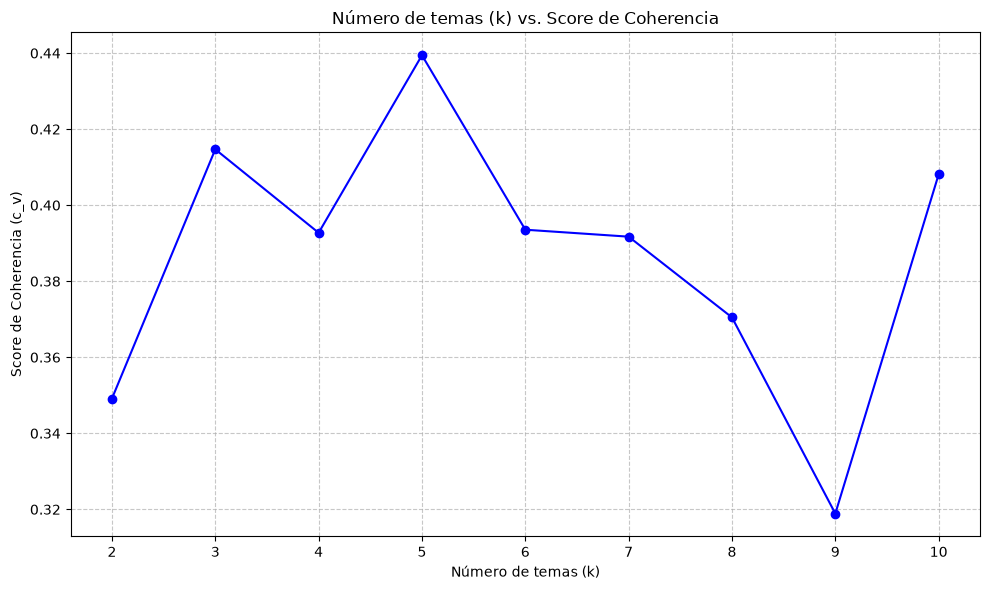

In [26]:
# Calcular valores de coherencia para k de 2 a 10
inicio, limite, paso = 2, 10, 1
coherence_scores = calculate_coherence_values(
    dictionary=dictionary, 
    corpus=corpus, 
    texts=tokenized_texts, 
    start=inicio, 
    limit=limite, 
    step=paso
)

# Generar la gráfica
plot_coherence(inicio, limite, paso, coherence_scores)

In [27]:
ks = list(range(inicio, limite + 1, paso))
tabla_coh = pd.DataFrame({"k": ks, "c_v": np.round(coherence_scores, 4)})
display(tabla_coh)

k_optimo = ks[int(np.argmax(coherence_scores))]
print(f"k con mayor coherencia: {k_optimo}")

,k,c_v
0,2,0.3491
1,3,0.4147
2,4,0.3927
3,5,0.4394
4,6,0.3935
5,7,0.3917
6,8,0.3705
7,9,0.3189
8,10,0.4081


k con mayor coherencia: 5


### 7.1 Latent Semantic Analysis (LSA)

Aplicamos TF-IDF y SVD para extraer los temas.

In [28]:
lsa_model, vectorizer_lsa, lsa_topics = run_lsa(
    textos_limpios, num_topics=k_optimo, top_n=10, extra_stopwords=SOURCE_BOILERPLATE
)

print(f"Top 10 palabras por tema usando LSA (k={k_optimo}):\n")
for tema, palabras in lsa_topics.items():
    print(f"{tema}: {', '.join(palabras)}")

Top 10 palabras por tema usando LSA (k=5):

Tema 1: catalunya, per, iniciativa, vers, gobierno, equo, pp, madrid, partido, presidente
Tema 2: vers, per, iniciativa, catalunya, equo, boluarte, canaria, coalicion, cs, riba
Tema 3: pnv, eaj, pp, equo, unidas, canarias, psoe, congreso, andalucia, coalicion
Tema 4: eaj, pnv, nueva, bng, canarias, ley, maestre, rita, echenique, reforma
Tema 5: madrid, comunidad, partido, pablo, presidenta, elecciones, echenique, ayuso, pp, vox


**Interpretación de los temas (LSA, k = 5):**

* **Tema 1 (Política nacional y catalana):** Combina vocabulario de gobierno central (*gobierno, pp, madrid, partido, presidente*) con la denominación de la coalición *catalunya, iniciativa, vers, per, equo*.
* **Tema 2 (Coalición verde/regional):** Presenta una fuerte redundancia con el Tema 1 (*vers, per, iniciativa, catalunya, equo*), incorporando nombres propios y siglas de partidos (*boluarte, canaria, cs, riba*).
* **Tema 3 (Partidos regionalistas y pactos):** Agrupa siglas de formaciones de comunidades autónomas y representación parlamentaria (*pnv, eaj, pp, equo, unidas, canarias, psoe, congreso, andalucia*).
* **Tema 4 (Reformas legislativas y bloques regionales):** Enfocado en actividad de partidos regionales y proyectos normativos (*eaj, pnv, nueva, bng, canarias, ley, reforma*). Se solapa conceptualmente con el Tema 3.
* **Tema 5 (Política de Madrid y elecciones):** El tema más delimitado e interpretable (*madrid, comunidad, presidenta, elecciones, ayuso, pp, vox, echenique, pablo*).

**Evaluación de LSA:**
El modelo LSA sufre de redundancia estructural (los temas 1–2 y 3–4 son muy similares). Esto se debe a que la descomposición por SVD sobre TF-IDF captura la coocurrencia estricta de cadenas de palabras y nombres de entidades muy repetidas (como "Iniciativa per Catalunya Verds"), más que agrupar conceptos semánticos abstractos.

### 7.2 Latent Dirichlet Allocation (LDA)

Aplicamos LDA utilizando Bag of Words y Gensim con el mismo número de temas.

In [29]:
lda_model, lda_topics = run_lda(corpus, dictionary, num_topics=k_optimo, top_n=10)

print(f"Top 10 palabras por tema usando LDA (k={k_optimo}):\n")
for tema, palabras in lda_topics.items():
    print(f"{tema}: {', '.join(palabras)}")


Top 10 palabras por tema usando LDA (k=5):

Tema 1: gobierno, pais, segun, españa, presidente, dijo, paises, ser, años, latina
Tema 2: gobierno, pp, sanchez, congreso, podemos, ley, psoe, partido, presidente, madrid
Tema 3: ceuta, video, personas, redes, sociales, marruecos, mensajes, migrantes, embargo, españa
Tema 4: años, colombia, venezuela, eeuu, pais, personas, noticias, caso, nacional, parte
Tema 5: catalunya, iniciativa, per, vers, madrid, gobierno, equo, andalucia, canaria, supremo


**Interpretación de los temas (LDA, k = 5):**

* **Tema 1 (Periodismo e información general / América Latina):** Declaraciones oficiales y reportajes informativos sobre España e Hispanoamérica (*gobierno, país, según, españa, presidente, dijo, países, latina*).
* **Tema 2 (Política interior española y Congreso):** Debate político nacional, actividad parlamentaria e interacción entre partidos (*gobierno, pp, sanchez, congreso, podemos, ley, psoe, partido, madrid*).
* **Tema 3 (Desinformación viral y redes sociales):** Difusión de contenidos virales, mensajes en redes y cobertura de crisis migratorias/frontera (*ceuta, video, personas, redes, sociales, marruecos, mensajes, migrantes*).
* **Tema 4 (Geopolítica e internacional):** Noticiero internacional enfocado en coyuntura política y sucesos en América Latina y EE.UU. (*colombia, venezuela, eeuu, pais, noticias, caso*).
* **Tema 5 (Coaliciones y partidos autonómicos):** Agrupa formaciones regionales (Cataluña, Andalucía, Canarias), coaliciones y referencias al ámbito judicial (*catalunya, iniciativa, per, vers, equo, andalucia, canaria, supremo*).

---

### Conclusión del Modelado de Temas

El modelo **LDA se consolida como la técnica superior** respecto a LSA:
1. **Reducción del solapamiento:** LDA logró separar de forma limpia la política nacional (Tema 2), la desinformación viral (Tema 3), la geopolítica (Tema 4) y las coaliciones regionales (Tema 5), a diferencia de LSA donde la mayoría de componentes repetían siglas partidistas.
2. **Capacidad predictiva y descriptiva:** LDA aisló en el **Tema 3** el lenguaje propio de la posverdad y propagación en plataformas digitales (*redes, sociales, video, mensajes, migrantes*), lo que constituye un pilar semántico fundamental para caracterizar las noticias falsas del corpus.

## 8. ANÁLISIS DE TEMAS SEGÚN LA VERACIDAD DE LAS NOTICIAS 

Se determina el tema dominante para cada documento a partir del modelo de temas seleccionado. Posteriormente, se evalúa la distribución porcentual de los temas entre noticias verdaderas (`label=1`) y falsas (`label=0`).

In [32]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from src.topic_analysis import (
    get_dominant_topic, compute_topic_distribution_table, plot_topic_comparison
)

topic_labels = {
    0: "Periodismo Informativo e Internacional",
    1: "Política Interior y Poder Legislativo",
    2: "Desinformación Viral y Redes Sociales",
    3: "Geopolítica y Coyuntura Internacional",
    4: "Coaliciones y Partidos Autonómicos",
}
topic_labels.update({
    index: f"Tema {index + 1}"
    for index in range(k_optimo)
    if index not in topic_labels
})

if topic_backend == "gensim":
    doc_topic_matrix = np.zeros((len(corpus), k_optimo))
    for i, bow in enumerate(corpus):
        for topic, probability in lda_model.get_document_topics(bow, minimum_probability=0):
            doc_topic_matrix[i, topic] = probability
    empty_documents = np.array([len(bow) == 0 for bow in corpus])
else:
    doc_topic_matrix = lda_model.transform(corpus)
    empty_documents = np.asarray(corpus.sum(axis=1)).ravel() == 0

print(f"Documentos sin tema (vacíos tras filtrar): {empty_documents.sum()}")
processed["dominant_topic"] = get_dominant_topic(doc_topic_matrix, topic_labels=topic_labels).values
processed_ok = processed[~empty_documents]

Documentos sin tema (vacíos tras filtrar): 0


In [33]:
topic_words = {topic_labels[i]: lda_topics[f"Tema {i+1}"] for i in topic_labels}

interpretations = {
    "Periodismo Informativo e Internacional": "Declaraciones oficiales y reportajes informativos sobre España e Hispanoamérica.",
    "Política Interior y Poder Legislativo": "Debate político nacional, actividad parlamentaria e interacción entre partidos.",
    "Desinformación Viral y Redes Sociales": "Difusión de contenidos virales, mensajes en redes y cobertura de crisis migratorias.",
    "Geopolítica y Coyuntura Internacional": "Noticiero internacional enfocado en política y sucesos de América Latina y EE.UU.",
    "Coaliciones y Partidos Autonómicos": "Formaciones regionales, coaliciones autonómicas y referencias al ámbito judicial."
}

topic_table = compute_topic_distribution_table(
    processed_ok, topic_column="dominant_topic", label_column="label",
    topic_words=topic_words, interpretations=interpretations,
)
display(topic_table)

chi2, p, _, _ = chi2_contingency(topic_table[["Verdaderas (cantidad)", "Falsas (cantidad)"]])
print(f"Chi-cuadrado = {chi2:.1f}, p = {p:.2e}")

,Tema,Palabras representativas,Verdaderas (cantidad),Verdaderas (%),Falsas (cantidad),Falsas (%),Interpretación
0,Coaliciones y Partidos Autonómicos,"catalunya, iniciativa, per, vers, madrid, gobi...",434,16.38,778,29.36,"Formaciones regionales, coaliciones autonómica..."
1,Desinformación Viral y Redes Sociales,"ceuta, video, personas, redes, sociales, marru...",83,3.13,134,5.06,"Difusión de contenidos virales, mensajes en re..."
2,Geopolítica y Coyuntura Internacional,"años, colombia, venezuela, eeuu, pais, persona...",358,13.51,141,5.32,Noticiero internacional enfocado en política y...
3,Periodismo Informativo e Internacional,"gobierno, pais, segun, españa, presidente, dij...",241,9.09,170,6.42,Declaraciones oficiales y reportajes informati...
4,Política Interior y Poder Legislativo,"gobierno, pp, sanchez, congreso, podemos, ley,...",1534,57.89,1427,53.85,"Debate político nacional, actividad parlamenta..."


Chi-cuadrado = 220.1, p = 1.77e-46


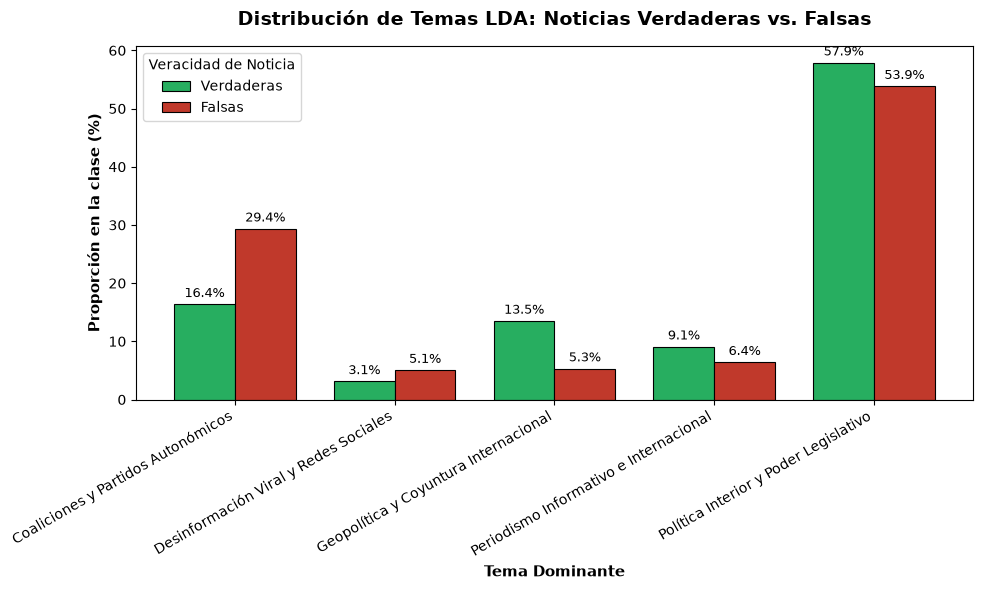

In [34]:
import matplotlib.pyplot as plt

(ROOT / "results").mkdir(exist_ok=True)
fig = plot_topic_comparison(topic_table, title="Distribución de Temas LDA: Noticias Verdaderas vs. Falsas")
display(fig)
fig.savefig(ROOT / "results" / "topics_comparison.png", dpi=160, bbox_inches="tight")
plt.close(fig)

### Análisis de la distribución temática según la veracidad de las noticias

La prueba chi-cuadrado (χ² = 220.1, p = 1.8e-46) indica que la distribución de temas **difiere significativamente** entre noticias verdaderas y falsas. Hay diferencias estadísticas reales, pero el solapamiento en el tema principal sugiere que la temática por sí sola no separa perfectamente las clases.

**Temas con mayor presencia proporcional en noticias falsas**

* **Coaliciones y Partidos Autonómicos:** 29.4% de las falsas frente a 16.4% de las verdaderas (+13.0 puntos, casi el doble). Es la asimetría más pronunciada. El vocabulario dominante (*catalunya, iniciativa, per, vers*) refleja una repetición masiva de la coalición "Iniciativa per Catalunya Verds" en el subconjunto de noticias falsas, indicando un artefacto específico de los datos recopilados más que un rasgo universal de la posverdad.
* **Desinformación Viral y Redes Sociales:** 5.1% de las falsas frente a 3.1% de las verdaderas (+2.0 puntos). Aunque minoritario en volumen, concentra orgánicamente el lenguaje de propagación engañosa y crisis fronterizas (*ceuta, video, redes, migrantes*).

**Temas con mayor presencia proporcional en noticias verdaderas**

* **Geopolítica y Coyuntura Internacional:** 13.5% frente a 5.3% (+8.2 puntos, más del doble).
* **Periodismo Informativo e Internacional:** 9.1% frente a 6.4% (+2.7 puntos).
* **Política Interior y Poder Legislativo:** 57.9% frente a 53.9% (+4.0 puntos). Al englobar a más de la mitad de los documentos en ambas clases, este eje temático actúa como la base discursiva del corpus y aporta poca capacidad discriminativa directa.

**Conclusión sobre el comportamiento temático**
Sí existen diferencias proporcionales claras: la desinformación en este dataset tiende a concentrarse en la política regional/autonómica y narrativas virales, mientras que la información veraz domina los reportajes sobre geopolítica y asuntos exteriores. No obstante, dado que el ~55% de ambos grupos comparte el mismo tema de "Política Interior", el contenido temático debe combinarse con el análisis de otras características (como la ponderación TF-IDF o patrones léxicos) para clasificar los textos con alta precisión.

## 9. Análisis integrado del corpus

Se integran los resultados de POS Tagging, NER y Topic Modeling para identificar patrones lingüísticos y semánticos que diferencien las noticias falsas y verdaderas.

In [36]:
%load_ext autoreload
%autoreload 2

In [37]:
from src.integrated_analysis import compare_pos, compare_ner, topics_table, recommendations

pos_comparison = compare_pos(pos_table)
ner_comparison = compare_ner(ner_type_distribution)
lsa_topic_table = topics_table(lsa_topics, "LSA")
lda_topic_table = topics_table(lda_topics, "LDA")

display(pos_comparison)
display(ner_comparison)
display(lsa_topic_table)
display(lda_topic_table)

,Verdaderas (%),Falsas (%),diferencia_falsas_menos_verdaderas
POS,,,
NOUN,45.08,47.31,2.23
VERB,22.59,22.76,0.17
ADJ,14.95,15.06,0.11
ADV,7.08,6.09,-0.99
PRON,10.31,8.78,-1.53


clase,Falsas,Verdaderas,diferencia_falsas_menos_verdaderas
tipo,,,
ORG,19.758747,16.671079,3.09
PER,25.162143,25.025529,0.14
LOC,31.573512,33.149276,-1.58
MISC,23.505598,25.154117,-1.65


,metodo,topico,palabras
0,LSA,Tema 1,"catalunya, per, iniciativa, vers, gobierno, eq..."
1,LSA,Tema 2,"vers, per, iniciativa, catalunya, equo, boluar..."
2,LSA,Tema 3,"pnv, eaj, pp, equo, unidas, canarias, psoe, co..."
3,LSA,Tema 4,"eaj, pnv, nueva, bng, canarias, ley, maestre, ..."
4,LSA,Tema 5,"madrid, comunidad, partido, pablo, presidenta,..."


,metodo,topico,palabras
0,LDA,Tema 1,"gobierno, pais, segun, españa, presidente, dij..."
1,LDA,Tema 2,"gobierno, pp, sanchez, congreso, podemos, ley,..."
2,LDA,Tema 3,"ceuta, video, personas, redes, sociales, marru..."
3,LDA,Tema 4,"años, colombia, venezuela, eeuu, pais, persona..."
4,LDA,Tema 5,"catalunya, iniciativa, per, vers, madrid, gobi..."


### Patrones identificados

1. **Predominio de sustantivos y diferencias en pronombres y adverbios.** Los sustantivos son la categoría principal en ambas clases. Las noticias falsas tienen una proporción mayor de sustantivos, mientras que las verdaderas presentan más pronombres y adverbios. Esta señal puede reflejar diferencias de estilo, pero debe normalizarse por longitud y combinarse con otras variables.

2. **Diferencias en tipos de entidades.** Los lugares son el tipo NER más frecuente en ambas clases. Las noticias verdaderas tienen mayor proporción de `LOC` y `MISC`, mientras que las falsas tienen mayor proporción de `ORG`. La comparación debe controlarse por fuente, pues el dataset y el scraping pueden tratar temas diferentes.

3. **Concentración temática política y territorial.** Los tópicos LSA/LDA muestran términos asociados con gobierno, partidos, Congreso, Cataluña, Canarias y procesos electorales. En conjunto con las entidades recurrentes, esto indica que la diferencia entre clases no depende solamente del vocabulario, sino también de los actores, lugares y conflictos políticos mencionados.

### Uso en un detector automático

Estos patrones pueden utilizarse como información adicional, no como reglas deterministas. Se recomienda incorporar proporciones POS, conteos de entidades NER normalizados por número de tokens y distribución de tópicos como características numéricas junto con TF-IDF. La evaluación debe realizarse con validación cruzada y separando, cuando sea posible, documentos por fuente para evitar que el modelo aprenda el origen en lugar de la clase.

In [38]:
display(recommendations())

,señal,variables,uso
0,Distribución POS,"proporción de NOUN, ADV y PRON",añadir como características numéricas
1,Entidades NER,"conteos por LOC, PER, ORG y MISC",añadir frecuencias normalizadas por documento
2,Temas,distribución de tópicos LSA/LDA,combinar con TF-IDF para capturar contexto sem...


In [39]:
# Tablas integradas para el informe.
RESULTS_INTEGRATED_DIR = ROOT / "results" / "integrated"
RESULTS_INTEGRATED_DIR.mkdir(parents=True, exist_ok=True)

display(pos_comparison)
display(ner_comparison)
display(lsa_topic_table)
display(lda_topic_table)
display(recommendations())

pos_comparison.to_csv(RESULTS_INTEGRATED_DIR / "pos_comparison.csv")
ner_comparison.to_csv(RESULTS_INTEGRATED_DIR / "ner_comparison.csv")
lsa_topic_table.to_csv(RESULTS_INTEGRATED_DIR / "lsa_topics.csv", index=False)
lda_topic_table.to_csv(RESULTS_INTEGRATED_DIR / "lda_topics.csv", index=False)
recommendations().to_csv(RESULTS_INTEGRATED_DIR / "classification_recommendations.csv", index=False)

,Verdaderas (%),Falsas (%),diferencia_falsas_menos_verdaderas
POS,,,
NOUN,45.08,47.31,2.23
VERB,22.59,22.76,0.17
ADJ,14.95,15.06,0.11
ADV,7.08,6.09,-0.99
PRON,10.31,8.78,-1.53


clase,Falsas,Verdaderas,diferencia_falsas_menos_verdaderas
tipo,,,
ORG,19.758747,16.671079,3.09
PER,25.162143,25.025529,0.14
LOC,31.573512,33.149276,-1.58
MISC,23.505598,25.154117,-1.65


,metodo,topico,palabras
0,LSA,Tema 1,"catalunya, per, iniciativa, vers, gobierno, eq..."
1,LSA,Tema 2,"vers, per, iniciativa, catalunya, equo, boluar..."
2,LSA,Tema 3,"pnv, eaj, pp, equo, unidas, canarias, psoe, co..."
3,LSA,Tema 4,"eaj, pnv, nueva, bng, canarias, ley, maestre, ..."
4,LSA,Tema 5,"madrid, comunidad, partido, pablo, presidenta,..."


,metodo,topico,palabras
0,LDA,Tema 1,"gobierno, pais, segun, españa, presidente, dij..."
1,LDA,Tema 2,"gobierno, pp, sanchez, congreso, podemos, ley,..."
2,LDA,Tema 3,"ceuta, video, personas, redes, sociales, marru..."
3,LDA,Tema 4,"años, colombia, venezuela, eeuu, pais, persona..."
4,LDA,Tema 5,"catalunya, iniciativa, per, vers, madrid, gobi..."


,señal,variables,uso
0,Distribución POS,"proporción de NOUN, ADV y PRON",añadir como características numéricas
1,Entidades NER,"conteos por LOC, PER, ORG y MISC",añadir frecuencias normalizadas por documento
2,Temas,distribución de tópicos LSA/LDA,combinar con TF-IDF para capturar contexto sem...


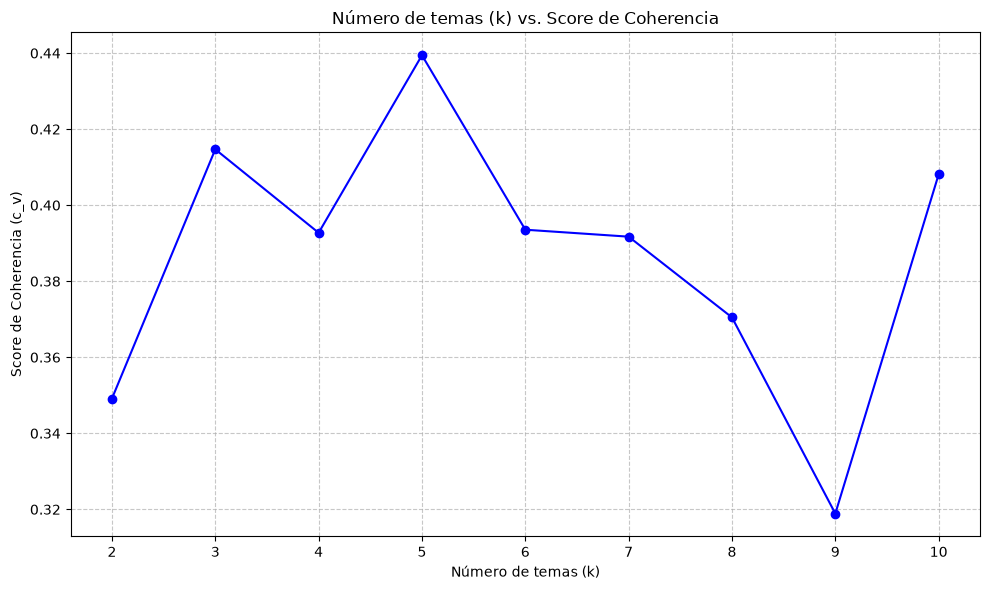

In [40]:
# Gráfica de coherencia usada para justificar el número de temas.
coherence_figure = plot_coherence(inicio, limite, paso, coherence_scores)
display(coherence_figure)
coherence_figure.savefig(RESULTS_INTEGRATED_DIR / "topic_coherence.png", dpi=160, bbox_inches="tight")
plt.close(coherence_figure)

Las gráficas POS y NER se generan y se muestran en sus respectivas secciones. En esta sección integrada se incorpora además la curva de coherencia, que permite justificar la selección de `k_optimo`, junto con las tablas de tópicos LSA/LDA y las variables propuestas para clasificación.

## 10. T?cnicas de aprendizaje utilizadas

Se comparan cuatro algoritmos, cuatro t?cnicas de reducci?n y dos ponderaciones. Se reserva el 20% del corpus para test y se aplica validaci?n cruzada estratificada de 10 pliegues sobre el 80% de entrenamiento.


In [36]:
from src.classify import (
    evaluate_classifiers, classification_table, plot_max_f1_by_algorithm,
    plot_mean_f1_by_weighting, plot_mean_f1_by_reduction,
    save_classification_results,
)

classification_results = evaluate_classifiers(
    processed, text_column="clean_text", label_column="label",
    test_size=0.2, cv=10, min_df=3, random_state=42,
)
classification_results.sort_values("f1_test", ascending=False).head(10)


,algoritmo,reduccion,ponderacion,n_caracteristicas,accuracy_cv,precision_cv,recall_cv,f1_cv,accuracy_test,precision_test,recall_test,f1_test
1,Árbol de decisión,Ninguna,TO,31129,0.877358,0.877747,0.877358,0.877326,0.892453,0.893400,0.892453,0.892388
9,Árbol de decisión,Solo stopwords,TO,15019,0.881604,0.881935,0.881604,0.881579,0.891509,0.892853,0.891509,0.891417
31,SVM,Stopwords + stemming,TF-IDF,13191,0.867453,0.872511,0.867453,0.866982,0.878302,0.880809,0.878302,0.878101
24,Regresión logística,Stopwords + stemming,TO,13191,0.869340,0.872400,0.869340,0.869055,0.875472,0.878577,0.875472,0.875216
15,SVM,Solo stopwords,TF-IDF,15019,0.875236,0.881296,0.875236,0.874703,0.872642,0.876124,0.872642,0.872346
25,Árbol de decisión,Stopwords + stemming,TO,13191,0.879953,0.880345,0.879953,0.879921,0.870755,0.871232,0.870755,0.870713
17,Árbol de decisión,Solo stemming,TO,28627,0.863915,0.864253,0.863915,0.863882,0.869811,0.870238,0.869811,0.869774
3,SVM,Ninguna,TO,31129,0.863443,0.864584,0.863443,0.863334,0.869811,0.871722,0.869811,0.869644
0,Regresión logística,Ninguna,TO,31129,0.874528,0.878268,0.874528,0.874195,0.867925,0.871228,0.867925,0.867630
8,Regresión logística,Solo stopwords,TO,15019,0.877123,0.880725,0.877123,0.876821,0.866038,0.868578,0.866038,0.865807


In [40]:
classification_comparison = classification_table(classification_results)
display(classification_comparison.style.format(precision=3))
print(f"Configuraciones evaluadas: {len(classification_results)}")
print("Cada fila representa una combinación de ponderación y reducción.")


#    POND STOPWORDS STEMMING Regresión logística                     Árbol de decisión                           KNN                           SVM                    
                                          PRECISION    RECALL  F1-SCORE         PRECISION    RECALL  F1-SCORE PRECISION    RECALL  F1-SCORE PRECISION    RECALL  F1-SCORE
0  1      TO     FALSE    FALSE            0.871228  0.867925  0.867630          0.893400  0.892453  0.892388  0.647155  0.614151  0.591231  0.871722  0.869811  0.869644
1  2      TO      TRUE    FALSE            0.868578  0.866038  0.865807          0.892853  0.891509  0.891417  0.769530  0.705660  0.687125  0.866191  0.865094  0.864993
2  3      TO     FALSE     TRUE            0.868242  0.865094  0.864805          0.870238  0.869811  0.869774  0.688200  0.636792  0.610172  0.860152  0.858491  0.858327
3  4      TO      TRUE     TRUE            0.878577  0.875472  0.875216          0.871232  0.870755  0.870713  0.769368  0.709434  0.692319  0.862126  0.861321  0.861244
4  5  TF-IDF     FALSE    FALSE            0.858311  0.850943  0.850173          0.855763  0.855660  0.855650  0.747858  0.746226  0.745808  0.863113  0.860377  0.860114
5  6  TF-IDF      TRUE    FALSE            0.874475  0.864151  0.863208          0.861476  0.861321  0.861306  0.815094  0.811321  0.810754  0.876124  0.872642  0.872346
6  7  TF-IDF     FALSE     TRUE            0.855684  0.847170  0.846250          0.851888  0.851887  0.851887  0.736056  0.734906  0.734582  0.860143  0.857547  0.857290
7  8  TF-IDF      TRUE     TRUE            0.869663  0.860377  0.859495          0.853926  0.853774  0.853758  0.783950  0.780189  0.779458  0.880809  0.878302  0.878101

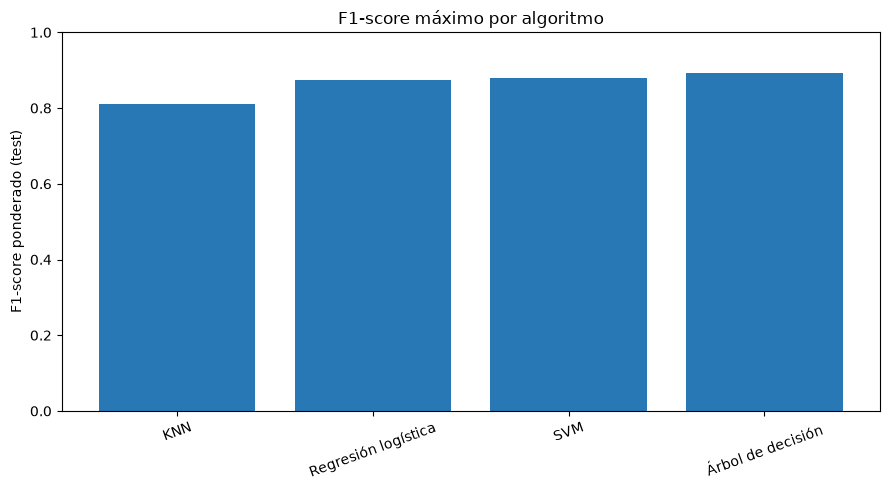

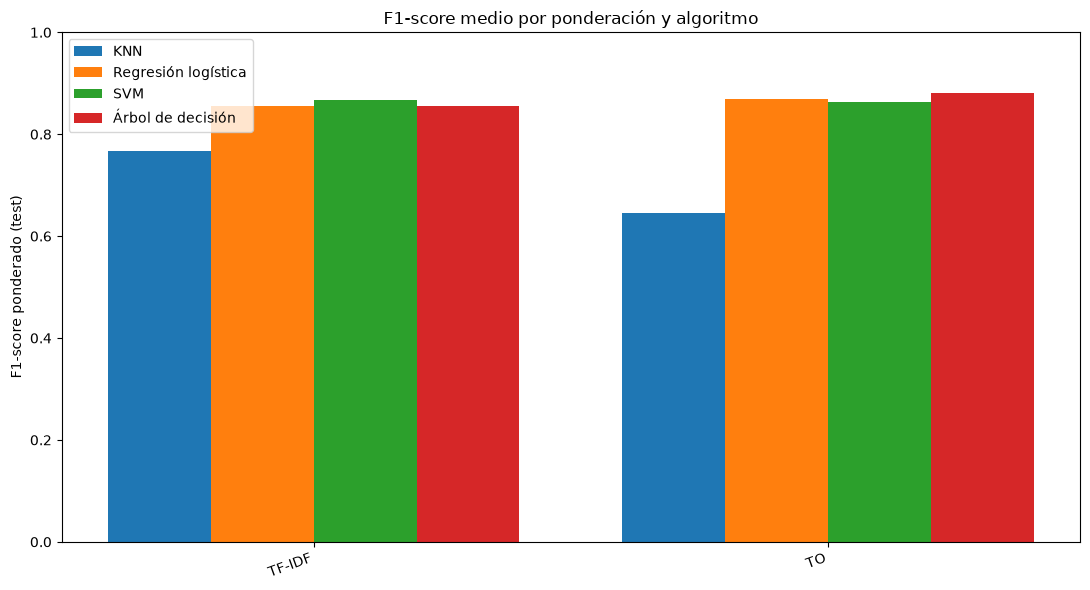

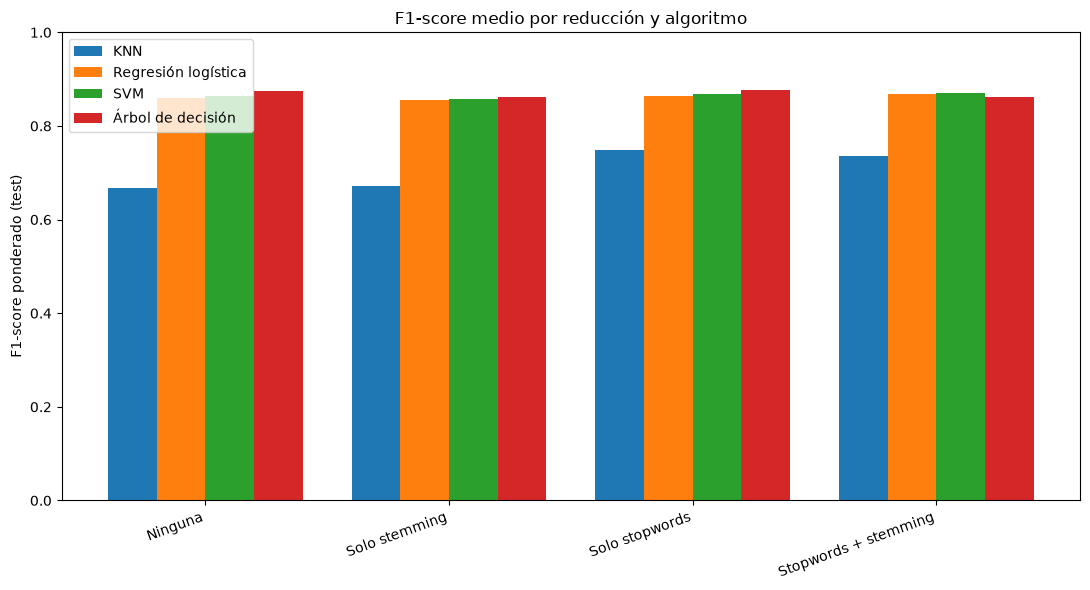

In [38]:
classification_figures = [
    plot_max_f1_by_algorithm(classification_results),
    plot_mean_f1_by_weighting(classification_results),
    plot_mean_f1_by_reduction(classification_results),
]
for figure in classification_figures:
    display(figure)
    plt.close(figure)


In [39]:
RESULTS_CLASSIFICATION_DIR = ROOT / "results" / "classification"
classification_paths = save_classification_results(
    classification_results, RESULTS_CLASSIFICATION_DIR
)
classification_paths


{'table': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/classification/classification_results.csv'),
 'f1_max_algorithm.png': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/classification/f1_max_algorithm.png'),
 'f1_mean_weighting_algorithm.png': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/classification/f1_mean_weighting_algorithm.png'),
 'f1_mean_reduction_algorithm.png': WindowsPath('C:/UNI/2026-2/PLN/Practica01/results/classification/f1_mean_reduction_algorithm.png')}

### Interpretaci?n de los resultados

La comparaci?n debe centrarse en el F1 ponderado, considerando tanto el comportamiento medio en validaci?n cruzada como el resultado del conjunto de test. No se realiza b?squeda de hiperpar?metros: las diferencias observadas corresponden a los algoritmos, las ponderaciones y las t?cnicas de reducci?n evaluadas.
